In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [ ]:
# 1) Chargement des données
import pandas as pd

# Recharger les fichiers
fact_sales = pd.read_csv('fact_sales.csv')
dim_customers = pd.read_csv('dim_customers.csv')
dim_products = pd.read_csv('dim_products.csv', encoding='latin-1')
state_mapping = pd.read_csv('state_region_mapping.csv')

# Nettoyage
dim_products = dim_products.drop_duplicates(subset=['Stock Code'])

# Fusion
df = fact_sales.merge(
    dim_products[['Stock Code', 'Weight', 'Landed Cost', 'Category']],
    on='Stock Code',
    how='left'
)

df = df.merge(
    dim_customers[['Customer ID', 'Order State']],
    on='Customer ID',
    how='left'
)

df = df.merge(
    state_mapping[['Order State', 'Region']].drop_duplicates(),
    on='Order State',
    how='left'
)

# Nettoyage valeurs manquantes
df = df.dropna(subset=['Sales', 'Quantity', 'Unit Price'])
df['Weight'] = df['Weight'].fillna(df['Weight'].median())
df['Region'] = df['Region'].fillna('Unknown')
df['Category'] = df['Category'].fillna('Other')



In [ ]:
# 2) EDA (Exploration)
print("--- Analyse des manquants ---")
print(df.isnull().sum())
# Traitement rapide des manquants
df = df.dropna(subset=['Sales', 'Quantity', 'Unit Price'])
df['Weight'] = df['Weight'].fillna(df['Weight'].median())
df['Region'] = df['Region'].fillna('Unknown')
df['Category'] = df['Category'].fillna('Other')


--- Analyse des manquants ---
Transaction Date       0
Customer ID         4416
Description            0
Stock Code             0
Invoice No           661
Quantity               0
Sales                  0
Unit Price             0
Weight                 0
Landed Cost            0
Category               0
Order State         4416
Region                 0
dtype: int64


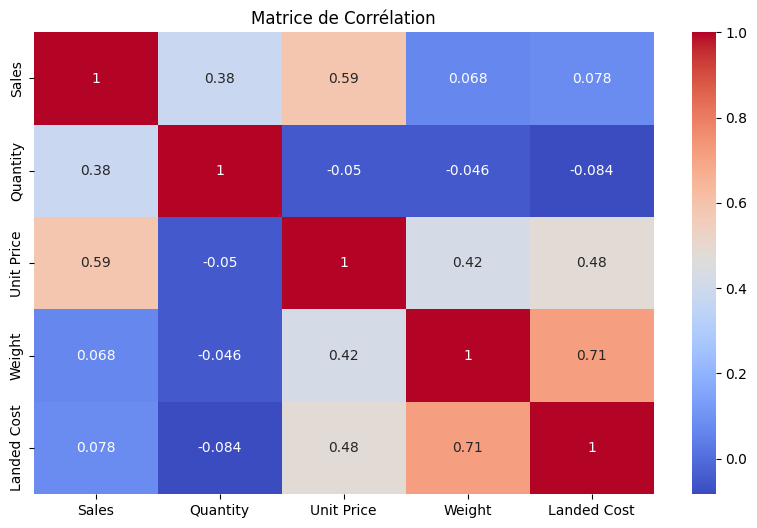

In [ ]:
# 3) Corrélation
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Sales', 'Quantity', 'Unit Price', 'Weight', 'Landed Cost']].corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de Corrélation")
plt.show()


💰 Sales (Ventes)
Unit Price (0.59) → corrélation modérée à forte

* Plus le prix augmente, plus les ventes augmentent (probablement produits premium)

Quantity (0.38) → corrélation modérée

* Les ventes augmentent avec la quantité, mais pas fortement (logique mais pas dominant)

Weight (0.068) et Landed Cost (0.078) → très faibles

*Peu d’impact direct sur les ventes

➡️ Le facteur principal ici est le prix unitaire, pas le volume ni les coûts logistiques
📦 Quantity (Quantité)
Corrélations faibles ou négatives avec tout :
Unit Price (-0.05)
Weight (-0.046)
Landed Cost (-0.084)

➡️ Variable assez indépendante
➡️ Légère tendance : plus le prix/coût augmente, moins on vend en volume (logique économique)

💲 Unit Price (Prix unitaire)
Sales (0.59) → relation importante
Weight (0.42) → modérée
Landed Cost (0.48) → modérée

➡️ Les produits plus chers :
sont souvent plus lourds oûtent plus cher à importer
➡️ Cohérence logique (produits premium ou complexes)
⚖️ Weight (Poids)
Landed Cost (0.71) → corrélation forte

➡️ Le poids est un driver majeur du coût logistique

🚢 Landed Cost (Coût total import)
Fortement lié à :
Weight (0.71)
Unit Price (0.48)

➡️ Le coût dépend surtout :
du poids (transport)
du prix (taxes, assurance, etc.)



In [ ]:
# 4) Préparer X et y
features = ['Quantity', 'Unit Price','Weight', 'Category', 'Region']
X = pd.get_dummies(df[features], drop_first=True) # Encodage des variables catégorielles
y = df['Sales']
# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 5) Modèle 1 : Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:

# 6) MODÈLE 2 : Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
# MODÈLE 3 : XGBoost Regressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

# prédiction
y_pred_xgb = xgb.predict(X_test)

In [ ]:
# 7) COMPARAISON DES MODÈLES
metrics = {
    'R2 Score (Précision)': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],

    'MAE (Erreur Moyenne $)': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
}

comparison_df = pd.DataFrame(
    metrics,
    index=['Linear Regression', 'Random Forest', 'XGBoost']
)

print(comparison_df.round(3))

                   R2 Score (Précision)  MAE (Erreur Moyenne $)     RMSE
Linear Regression                 0.579                  44.247  109.585
Random Forest                     0.860                   2.395   63.077
XGBoost                           0.895                   2.988   54.701


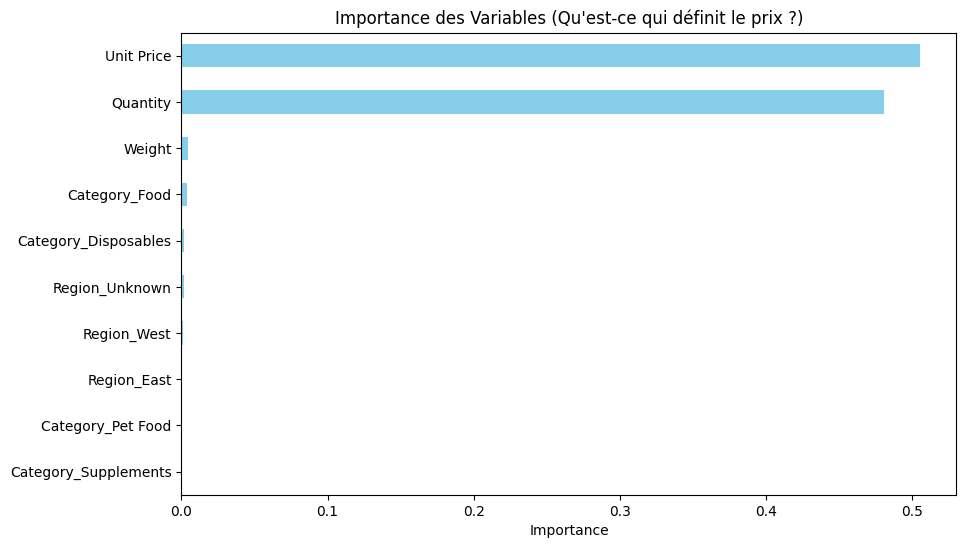

In [ ]:
# 9) FEATURE IMPORTANCE
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance_df.tail(10).plot(kind='barh', color='skyblue')
plt.title("Importance des Variables (Qu'est-ce qui définit le prix ?)")
plt.xlabel("Importance")
plt.show()

In [ ]:
# ==============================
# PRÉDICTION D'UNE NOUVELLE VENTE
# ==============================

import pandas as pd

# Nouvelle donnée à prédire
new_data = pd.DataFrame({
    'Quantity': [5],
    'Weight': [1.2],
  'Unit Price':[11.5],
    'Category': ['Electronics'],
    'Region': ['West']
})

# Encoder comme les données d'entraînement
new_data_encoded = pd.get_dummies(new_data)

# Aligner les colonnes avec X
new_data_encoded = new_data_encoded.reindex(columns=X.columns, fill_value=0)

# Prédiction avec XGBoost
prediction_xgb = xgb.predict(new_data_encoded)

# Résultat
print("Prédiction de la nouvelle vente :", round(prediction_xgb[0], 2), "$")

Prédiction de la nouvelle vente : 52.2 $


In [ ]:
import joblib

# Sauvegarder le modèle XGBoost
joblib.dump(xgb, "sales_xgboost.pkl")

# Sauvegarder les colonnes
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Modèle sauvegardé avec succès")

Modèle sauvegardé avec succès
